In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

                 run_id  n_enrichment  pssm_weight  perc_rank_start  \
3   ne19_pw0.66_prs9.80            19     0.656992         9.804038   
7   ne19_pw0.66_prs9.80            19     0.656992         9.804038   
11  ne19_pw0.66_prs9.80            19     0.656992         9.804038   
15  ne19_pw0.71_prs2.06            19     0.705065         2.057386   
19  ne19_pw0.71_prs2.06            19     0.705065         2.057386   

    mean_auc01     peptide     auc01  step  n_total  n_top  
3     0.749867   LLWNGPMAV  0.826698     3     8700    382  
7     0.749867  ELAGIGILTV  0.753709     3     8725    148  
11    0.749867   GILGFVFTL  0.669194     3     8900    485  
15    0.739381   LLWNGPMAV  0.815022     3     8725    726  
19    0.739381  ELAGIGILTV  0.712472     3     8725    269  


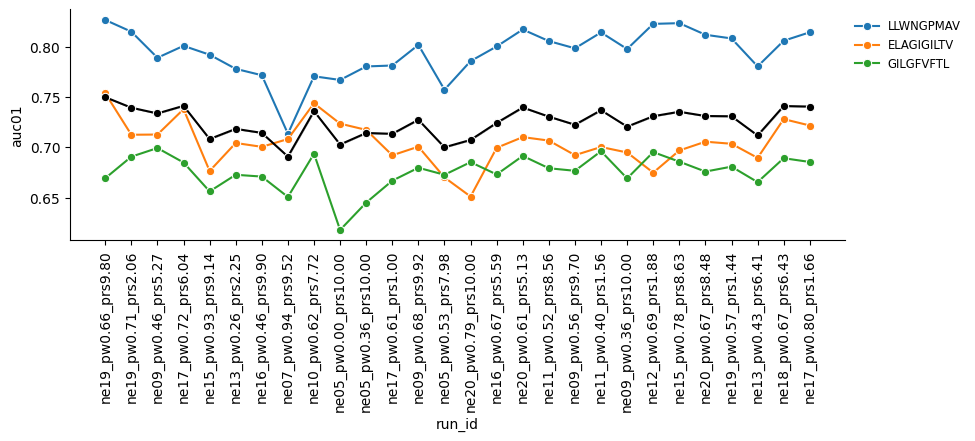

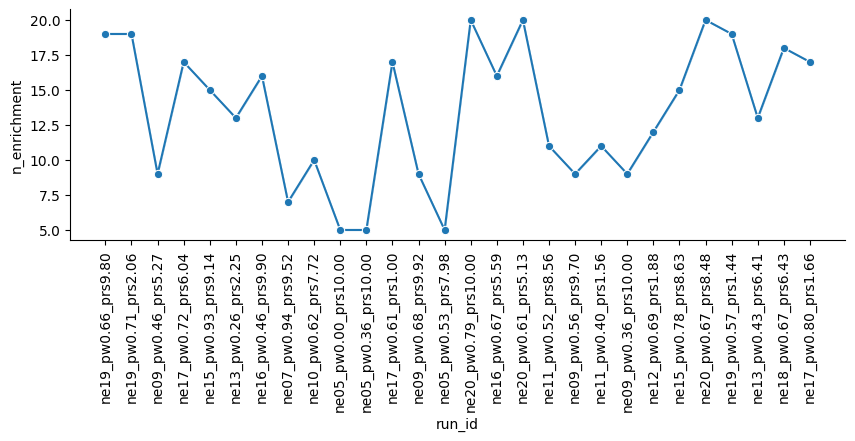

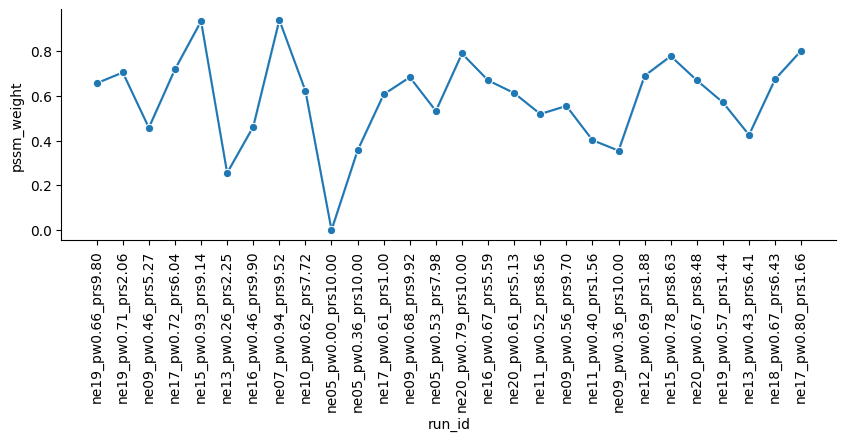

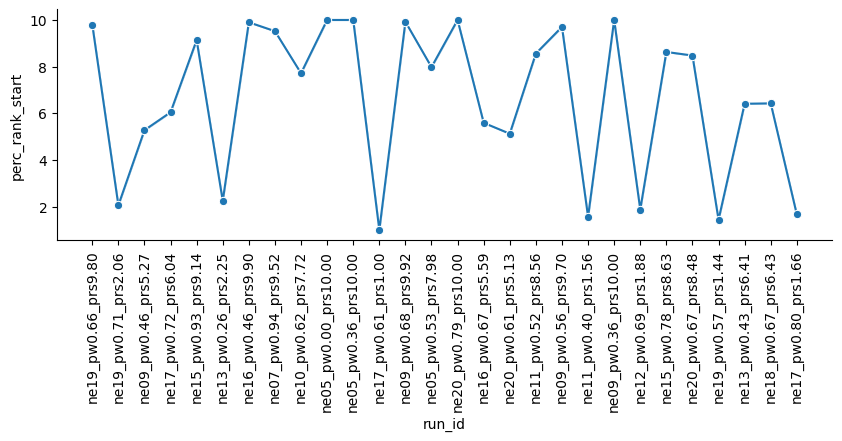

In [16]:
df = pd.read_csv('optimizer_runs/bayes_history.csv')
df = df[df['step'] == 3]
print(df.head())
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='auc01', hue='peptide', ax=ax, marker='o')
sns.lineplot(df, x='run_id', y='mean_auc01', ax=ax, marker='o', color='black')
ax.tick_params(axis='x', rotation=90)

ax.legend(bbox_to_anchor=(1,1), frameon=False, fontsize='small')
sns.despine()


fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='n_enrichment', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='pssm_weight', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
sns.lineplot(df, x='run_id', y='perc_rank_start', ax=ax, marker='o')
ax.tick_params(axis='x', rotation=90)
sns.despine()

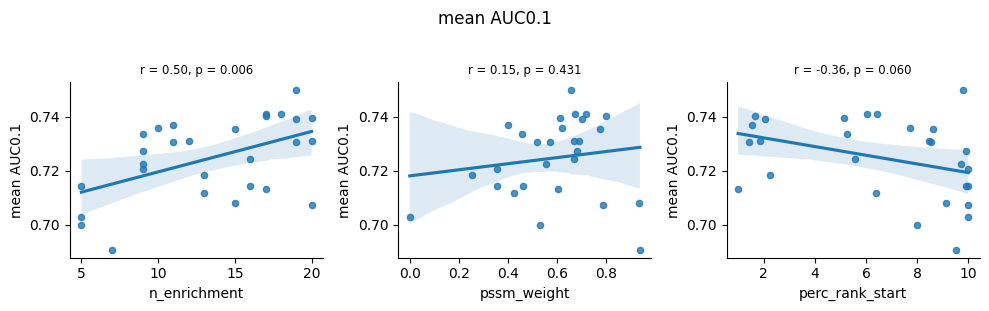

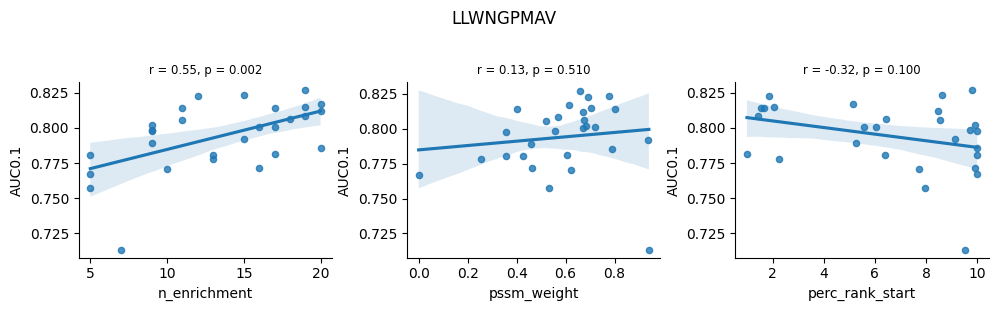

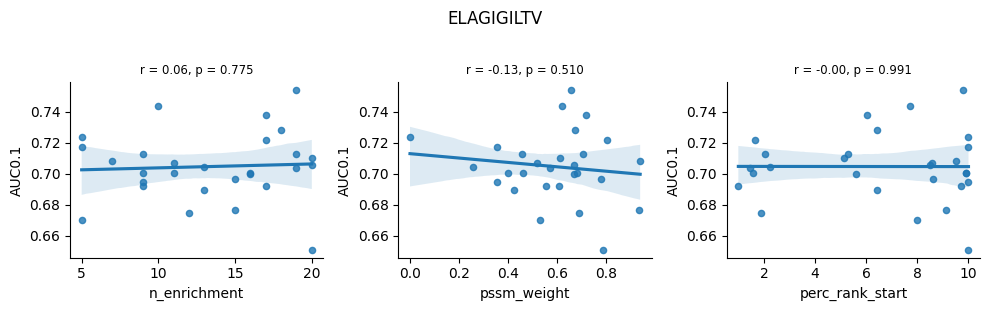

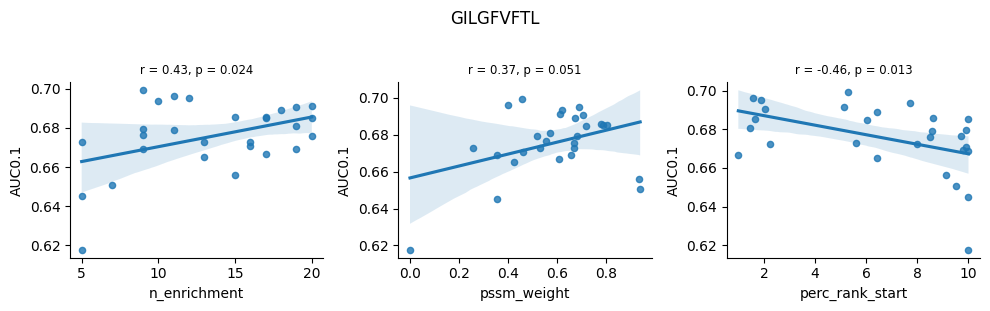

In [20]:
from scipy import stats

params = ['n_enrichment', 'pssm_weight', 'perc_rank_start']
peptides = df['peptide'].unique()

# mean auc01 correlations
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, param in zip(axes, params):
    df_corr = df[['mean_auc01', param]].drop_duplicates()
    r, p = stats.pearsonr(df_corr[param], df_corr['mean_auc01'])
    sns.regplot(df_corr, x=param, y='mean_auc01', ax=ax, scatter_kws={'s': 20})
    ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize='small')
    ax.set_xlabel(param)
    ax.set_ylabel('mean AUC0.1')
plt.suptitle('mean AUC0.1', y=1.02)
plt.tight_layout()
sns.despine()

# per-peptide correlations
for peptide in peptides:
    df_pep = df[df['peptide'] == peptide]
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    for ax, param in zip(axes, params):
        r, p = stats.pearsonr(df_pep[param], df_pep['auc01'])
        sns.regplot(df_pep, x=param, y='auc01', ax=ax, scatter_kws={'s': 20})
        ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize='small')
        ax.set_xlabel(param)
        ax.set_ylabel('AUC0.1')
    plt.suptitle(peptide, y=1.02)
    plt.tight_layout()
    sns.despine()